In [1]:
import pandas as pd
import numpy as np

# Plot graph
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
from google.colab import files


In [2]:
df = pd.read_csv("/content/aug_train.csv")

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [4]:
df.shape

(19158, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum().sort_values(ascending=False)

,0
company_type,6140
company_size,5938
gender,4508
major_discipline,2813
education_level,460
last_new_job,423
enrolled_university,386
experience,65
enrollee_id,0
city,0


In [8]:
target_condition = df['education_level'].isin(['High School', 'Primary School']) & df['major_discipline'].isna()
count_before = target_condition.sum()
count_before

np.int64(2325)

In [9]:
df.loc[target_condition, 'major_discipline'] = 'No Major'

In [10]:
count_after = (df['education_level'].isin(['High School', 'Primary School']) & df['major_discipline'].isna()).sum()
count_after

np.int64(0)

In [11]:
remaining_missing_mask = df['major_discipline'].isna() & ~df['education_level'].isin(['High School', 'Primary School'])
df_remaining = df[remaining_missing_mask]

In [12]:
print(df_remaining['education_level'].value_counts(dropna=False))

education_level
NaN         460
Graduate     22
Masters       6
Name: count, dtype: int64


In [13]:
print(df_remaining['relevent_experience'].value_counts())


relevent_experience
No relevent experience     260
Has relevent experience    228
Name: count, dtype: int64


In [14]:
print(df_remaining['experience'].value_counts().head())

experience
2      67
>20    61
3      51
5      46
4      35
Name: count, dtype: int64


In [15]:
print(df_remaining['company_type'].value_counts(dropna=False))

company_type
NaN                    312
Pvt Ltd                135
Public Sector           16
Early Stage Startup     14
Funded Startup           5
Other                    3
NGO                      3
Name: count, dtype: int64


In [16]:
graduates_main = df[df['education_level'].isin(['Graduate', 'Masters'])]

In [17]:
print(graduates_main[graduates_main['relevent_experience'] == 'No relevent experience']['major_discipline'].value_counts(normalize=True))

major_discipline
STEM               0.844227
Humanities         0.055284
Other              0.033688
Business Degree    0.030809
No Major           0.019292
Arts               0.016700
Name: proportion, dtype: float64


In [18]:
print(graduates_main[graduates_main['relevent_experience'] == 'Has relevent experience']['major_discipline'].value_counts(normalize=True))

major_discipline
STEM               0.897817
Humanities         0.036362
Other              0.020469
Business Degree    0.017419
Arts               0.015412
No Major           0.012522
Name: proportion, dtype: float64


In [19]:
print(df.groupby('company_type')['major_discipline'].value_counts(normalize=True).unstack())

major_discipline         Arts  Business Degree  Humanities  No Major  \
company_type                                                           
Early Stage Startup  0.022071         0.005093    0.027165  0.117148   
Funded Startup       0.017068         0.017068    0.050201  0.067269   
NGO                  0.025097         0.015444    0.083012  0.075290   
Other                0.008475         0.016949    0.076271  0.118644   
Public Sector        0.012780         0.010650    0.050053  0.082002   
Pvt Ltd              0.011568         0.018385    0.030985  0.089444   

major_discipline        Other      STEM  
company_type                             
Early Stage Startup  0.013582  0.814941  
Funded Startup       0.020080  0.828313  
NGO                  0.019305  0.781853  
Other                0.033898  0.745763  
Public Sector        0.024494  0.820021  
Pvt Ltd              0.018798  0.830820  


In [20]:
df['education_level'] = df['education_level'].fillna(df['education_level'].mode()[0])

In [21]:

smart_mode_matrix = df.groupby(['relevent_experience', 'company_type'])['major_discipline'].apply(
    lambda x: x.mode()[0] if not x.mode().empty else 'STEM'
).unstack()
smart_mode_matrix

company_type,Early Stage Startup,Funded Startup,NGO,Other,Public Sector,Pvt Ltd
relevent_experience,,,,,,
Has relevent experience,STEM,STEM,STEM,STEM,STEM,STEM
No relevent experience,STEM,STEM,STEM,STEM,STEM,STEM


In [22]:

smart_dist_matrix = df.groupby(['relevent_experience', 'company_type'])['major_discipline'].value_counts(normalize=True).unstack().fillna(0)
smart_dist_matrix

major_discipline                                 Arts  Business Degree  \
relevent_experience     company_type                                     
Has relevent experience Early Stage Startup  0.024145         0.004024   
                        Funded Startup       0.015556         0.014444   
                        NGO                  0.030220         0.019231   
                        Other                0.010526         0.010526   
                        Public Sector        0.014652         0.012821   
                        Pvt Ltd              0.010745         0.014970   
No relevent experience  Early Stage Startup  0.010870         0.010870   
                        Funded Startup       0.031250         0.041667   
                        NGO                  0.012987         0.006494   
                        Other                0.000000         0.043478   
                        Public Sector        0.010178         0.007634   
                        Pvt Ltd              0.016440         0.038599   

major_discipline                             Humanities  No Major     Other  \
relevent_experience     company_type                                          
Has relevent experience Early Stage Startup    0.024145  0.078471  0.014085   
                        Funded Startup         0.051111  0.056667  0.017778   
                        NGO                    0.071429  0.046703  0.016484   
                        Other                  0.073684  0.115789  0.031579   
                        Public Sector          0.038462  0.067766  0.020147   
                        Pvt Ltd                0.029579  0.066522  0.017989   
No relevent experience  Early Stage Startup    0.043478  0.326087  0.010870   
                        Funded Startup         0.041667  0.166667  0.041667   
                        NGO                    0.110390  0.142857  0.025974   
                        Other                  0.086957  0.130435  0.043478   
                        Public Sector          0.066158  0.101781  0.030534   
                        Pvt Ltd                0.039314  0.225161  0.023588   

major_discipline                                 STEM  
relevent_experience     company_type                   
Has relevent experience Early Stage Startup  0.855131  
                        Funded Startup       0.844444  
                        NGO                  0.815934  
                        Other                0.757895  
                        Public Sector        0.846154  
                        Pvt Ltd              0.860196  
No relevent experience  Early Stage Startup  0.597826  
                        Funded Startup       0.677083  
                        NGO                  0.701299  
                        Other                0.695652  
                        Public Sector        0.783715  
                        Pvt Ltd              0.656898

In [23]:
# 1. تحديد شرط الـ 488 صف المستهدفين
target_mask = df['major_discipline'].isna() & ~df['education_level'].isin(['High School', 'Primary School'])

# 2. هنعمل عمود مؤقت للصفوف الفاضية عشان نملأ بناءً على التوليفات
df.loc[target_mask, 'major_discipline'] = 'STEM'  # الديفولت العام بناءً على السيطرة

# 3. تطبيق شروط الفحص الخاصة (الـ NGO والـ Startups) بناءً على أرقامك:

# حالة 1: بدون خبرة + شركة ناشئة -> يذهب للـ No Major (بنسبة 32.6% في فحصك)
df.loc[target_mask & (df['relevent_experience'] == 'No relevent experience') & (df['company_type'] == 'Early Stage Startup'), 'major_discipline'] = 'No Major'

# حالة 2: بدون خبرة + NGO -> يذهب للـ No Major أو Humanities (لأنهم واصلين 14% و 11%)
df.loc[target_mask & (df['relevent_experience'] == 'No relevent experience') & (df['company_type'] == 'NGO'), 'major_discipline'] = 'No Major'

# حالة 3: مع وجود خبرة + NGO -> يظهر فيها الـ Humanities بنسبة (7.1%)
df.loc[target_mask & (df['relevent_experience'] == 'Has relevent experience') & (df['company_type'] == 'NGO'), 'major_discipline'] = 'Humanities'

# 4. معالجة الحالات المتبقية لو كان نوع الشركة نفسه NaN
df['major_discipline'] = df['major_discipline'].fillna('STEM')

In [24]:
print(df['major_discipline'].isna().sum())

0


In [25]:
print(df.isnull().sum().sort_values(ascending=False))

company_type              6140
company_size              5938
gender                    4508
last_new_job               423
enrolled_university        386
experience                  65
relevent_experience          0
city_development_index       0
enrollee_id                  0
city                         0
education_level              0
major_discipline             0
training_hours               0
target                       0
dtype: int64


In [26]:
print(df['experience'].value_counts(dropna=False))

experience
>20    3286
5      1430
4      1403
3      1354
6      1216
2      1127
7      1028
10      985
9       980
8       802
15      686
11      664
14      586
1       549
<1      522
16      508
12      494
13      399
17      342
19      304
18      280
20      148
NaN      65
Name: count, dtype: int64


In [27]:
# 1. دالة ذكية لتصنيف الموظفين بناءً على قيم عمود الـ experience الحالية
def assign_experience_status(val):
    if pd.isna(val):
        return 'Unknown'
    elif val == '<1':
        return 'Entry-Level'
    elif val == '>20':
        return 'Expert'
    else:
        # تحويل الأرقام النصية الحقيقية لـ int عشان نعمل عليها الشرط
        years = int(val)
        if years <= 2:
            return 'Entry-Level'
        elif 3 <= years <= 10:
            return 'Mid-Senior'
        else:
            return 'Senior'

# 2. إنشاء العمود الجديد Categorical
df['experience_status'] = df['experience'].apply(assign_experience_status)

In [28]:
print(df[df['experience'].isna()]['education_level'].value_counts())

education_level
Graduate          42
Masters           15
High School        4
Phd                3
Primary School     1
Name: count, dtype: int64


In [29]:
print(df[df['education_level'] == 'High School']['experience'].mode()[0])

3


In [30]:
print("Graduate Mode:", df[df['education_level'] == 'Graduate']['experience'].mode()[0])
print("Masters Mode :", df[df['education_level'] == 'Masters']['experience'].mode()[0])
print("Phd Mode     :", df[df['education_level'] == 'Phd']['experience'].mode()[0])

Graduate Mode: >20
Masters Mode : >20
Phd Mode     : >20


In [31]:
df.loc[df['experience'].isna() & (df['education_level'] == 'Primary School'), 'experience'] = '<1'
df.loc[df['experience'].isna() & (df['education_level'] == 'High School'), 'experience'] = '3'
df.loc[df['experience'].isna() & (df['education_level'].isin(['Graduate', 'Masters', 'Phd'])), 'experience'] = '>20'
df['experience_status'] = df['experience'].apply(assign_experience_status)

In [32]:
print(df['enrolled_university'].value_counts(dropna=False))

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
NaN                   386
Name: count, dtype: int64


In [33]:
print("Graduate Mode:", df[df['education_level'] == 'Graduate']['enrolled_university'].mode()[0])
print("Masters Mode :", df[df['education_level'] == 'Masters']['enrolled_university'].mode()[0])
print("Phd Mode     :", df[df['education_level'] == 'Phd']['enrolled_university'].mode()[0])

Graduate Mode: no_enrollment
Masters Mode : no_enrollment
Phd Mode     : no_enrollment


In [34]:
df['enrolled_university'] = df['enrolled_university'].fillna('no_enrollment')


In [35]:
print(df['enrolled_university'].value_counts(dropna=False))

enrolled_university
no_enrollment       14203
Full time course     3757
Part time course     1198
Name: count, dtype: int64


In [36]:
pd.crosstab(df['education_level'], df['enrolled_university'])

enrolled_university,Full time course,Part time course,no_enrollment
education_level,,,
Graduate,2278,805,8975
High School,864,166,987
Masters,557,204,3600
Phd,25,12,377
Primary School,33,11,264


In [37]:
print(df.isnull().sum().sort_values(ascending=False))

company_type              6140
company_size              5938
gender                    4508
last_new_job               423
city_development_index       0
city                         0
enrollee_id                  0
education_level              0
enrolled_university          0
relevent_experience          0
experience                   0
major_discipline             0
training_hours               0
target                       0
experience_status            0
dtype: int64


In [38]:
print(df['company_type'].value_counts(dropna=False))

company_type
Pvt Ltd                9817
NaN                    6140
Funded Startup         1001
Public Sector           955
Early Stage Startup     603
NGO                     521
Other                   121
Name: count, dtype: int64


In [39]:
print(df['company_size'].value_counts(dropna=False))

company_size
NaN          5938
50-99        3083
100-500      2571
10000+       2019
10/49        1471
1000-4999    1328
<10          1308
500-999       877
5000-9999     563
Name: count, dtype: int64


In [40]:
print(df[df['company_type'].isna()]['company_size'].value_counts(dropna=False))

company_size
NaN          5360
50-99         222
100-500       152
10/49         105
10000+         77
<10            65
500-999        64
1000-4999      59
5000-9999      36
Name: count, dtype: int64


In [41]:
common_na = df['company_type'].isna() & df['company_size'].isna()
df.loc[common_na, 'company_type'] = 'Unknown'
df.loc[common_na, 'company_size'] = 'Unknown'
common_na.value_counts()

,count
False,13798
True,5360


In [42]:
print(df.groupby(['relevent_experience', 'experience_status'])['company_type'].apply(lambda x: x.mode()[0] if not x.mode().empty else 'Pvt Ltd'))

relevent_experience      experience_status
Has relevent experience  Entry-Level          Pvt Ltd
                         Expert               Pvt Ltd
                         Mid-Senior           Pvt Ltd
                         Senior               Pvt Ltd
No relevent experience   Entry-Level          Unknown
                         Expert               Pvt Ltd
                         Mid-Senior           Unknown
                         Senior               Pvt Ltd
Name: company_type, dtype: object


In [43]:
df['company_type'] = df['company_type'].replace('Unknown', np.nan)
df['company_size'] = df['company_size'].replace('Unknown', np.nan)

In [44]:
print(pd.crosstab(df['relevent_experience'], df['company_type'], normalize='index') * 100)

company_type             Early Stage Startup  Funded Startup       NGO  \
relevent_experience                                                      
Has relevent experience             4.706426        8.368007  3.374942   
No relevent experience              4.266909        4.357694  7.081253   

company_type                Other  Public Sector    Pvt Ltd  
relevent_experience                                          
Has relevent experience  0.906149       5.159501  77.484975  
No relevent experience   1.044031      18.020881  65.229233  


In [45]:
print(pd.crosstab(df['experience_status'], df['company_type'], normalize='index') * 100)

company_type       Early Stage Startup  Funded Startup       NGO     Other  \
experience_status                                                            
Entry-Level                   9.360519        5.468026  6.024096  1.946247   
Expert                        2.131216        6.351860  4.220644  1.170079   
Mid-Senior                    5.508475        8.050847  3.911343  0.798566   
Senior                        3.313783        8.680352  3.372434  0.674487   

company_type       Public Sector    Pvt Ltd  
experience_status                            
Entry-Level             7.692308  69.508804  
Expert                  7.814459  78.311743  
Mid-Senior              7.561930  74.168840  
Senior                  6.480938  77.478006  


In [46]:
print(pd.crosstab(
    index=[df['relevent_experience'], df['experience_status']],
    columns=[df['education_level'], df['company_type']],
    normalize='index'
) * 100)

education_level                                      Graduate                 \
company_type                              Early Stage Startup Funded Startup   
relevent_experience     experience_status                                      
Has relevent experience Entry-Level                  8.870968       4.354839   
                        Expert                       1.118881       3.962704   
                        Mid-Senior                   3.834571       6.625176   
                        Senior                       1.987618       5.962854   
No relevent experience  Entry-Level                  4.357298       1.742919   
                        Expert                       0.403226       2.016129   
                        Mid-Senior                   2.337662       3.116883   
                        Senior                       0.879765       2.346041   

education_level                                                              \
company_type                            

In [47]:
def deterministic_company_type(row):
    if pd.notna(row['company_type']):
        return row['company_type']
    if (row['relevent_experience'] == 'No relevent experience' and
        row['experience_status'] == 'Expert' and
        row['education_level'] == 'Phd'):
        return 'Public Sector'
    elif (row['relevent_experience'] == 'No relevent experience' and
          row['experience_status'] == 'Mid-Senior' and
          row['education_level'] == 'Graduate'):
        return 'Public Sector'
    elif (row['relevent_experience'] == 'No relevent experience' and
          row['experience_status'] == 'Entry-Level' and
          row['education_level'] == 'Graduate'):
        return 'Early Stage Startup'

    else:
        return 'Pvt Ltd'
df['company_type'] = df.apply(deterministic_company_type, axis=1)

In [48]:
print(df['company_type'].value_counts())

company_type
Pvt Ltd                14455
Public Sector           1945
Early Stage Startup     1115
Funded Startup          1001
NGO                      521
Other                    121
Name: count, dtype: int64


In [49]:
print(pd.crosstab(
    index=[df['relevent_experience'], df['experience_status']],
    columns=[df['education_level'], df['company_size']],
    normalize='index'
) * 100)

education_level                             Graduate                       \
company_size                                   10/49    100-500 1000-4999   
relevent_experience     experience_status                                   
Has relevent experience Entry-Level        13.373860  10.486322  3.799392   
                        Expert              5.324074  12.453704  7.777778   
                        Mid-Senior          8.910134  14.359465  5.564054   
                        Senior              6.734113  12.045526  6.417958   
No relevent experience  Entry-Level         8.076010  11.401425  7.363420   
                        Expert              4.032258   6.048387  5.241935   
                        Mid-Senior          7.858546  10.314342  5.206287   
                        Senior              4.968944  11.801242  5.590062   

education_level                                                            \
company_size                                  10000+      50-99   500-999  

In [50]:
def deterministic_company_size(row):
    if pd.notna(row['company_size']):
        return row['company_size']
    if (row['relevent_experience'] == 'No relevent experience' and
        row['experience_status'] in ['Mid-Senior', 'Senior'] and
        row['education_level'] == 'Graduate'):
        return '10000+'
    elif (row['relevent_experience'] == 'Has relevent experience' and
          row['experience_status'] == 'Entry-Level' and
          row['education_level'] == 'Graduate'):
        return '10/49'
    elif (row['relevent_experience'] == 'Has relevent experience' and
          row['experience_status'] == 'Expert' and
          row['education_level'] == 'Graduate'):
        return '100-500'
    else:
        return '50-99'
df['company_size'] = df.apply(deterministic_company_size, axis=1)

In [51]:
print(df['company_size'].value_counts())

company_size
50-99        7281
10000+       3181
100-500      3052
10/49        1568
1000-4999    1328
<10          1308
500-999       877
5000-9999     563
Name: count, dtype: int64


In [52]:
print(df.isnull().sum().sort_values(ascending=False))

gender                    4508
last_new_job               423
city                         0
city_development_index       0
relevent_experience          0
enrolled_university          0
enrollee_id                  0
education_level              0
major_discipline             0
company_size                 0
experience                   0
company_type                 0
training_hours               0
target                       0
experience_status            0
dtype: int64


In [53]:
print(pd.crosstab(
    index=[df['experience_status'], df['target']],
    columns=df['last_new_job'],
    normalize='index'
) * 100)

last_new_job                      1          2         3         4         >4  \
experience_status target                                                        
Entry-Level       0.0     52.461538   9.923077  0.307692  0.461538   1.000000   
                  1.0     57.901391   9.734513  0.505689  0.252845   1.011378   
Expert            0.0     24.054735  13.179690  5.725603  6.697875  45.984876   
                  1.0     27.961165  15.145631  5.242718  6.796117  42.524272   
Mid-Senior        0.0     49.922529  16.516889  5.934304  5.268051   7.359777   
                  1.0     49.387110  17.081851  5.179913  4.982206   6.247529   
Senior            0.0     37.503491  17.844178  6.897515  7.511868  25.830774   
                  1.0     34.771574  14.340102  8.756345  8.248731  27.284264   

last_new_job                  never  
experience_status target             
Entry-Level       0.0     35.846154  
                  1.0     30.594185  
Expert            0.0      4.357220  

In [54]:
def super_smart_last_new_job(row):
    if pd.notna(row['last_new_job']):
        return row['last_new_job']
    if row['experience'] in ['<1', '0', 0] or row['education_level'] == 'Primary School':
        return 'never'
    combo_mode = df[
        (df['experience_status'] == row['experience_status']) &
        (df['relevent_experience'] == row['relevent_experience'])
    ]['last_new_job'].mode()
    if not combo_mode.empty:
        return combo_mode[0]
    else:
        return df['last_new_job'].mode()[0]
df['last_new_job'] = df.apply(super_smart_last_new_job, axis=1)
print(df['last_new_job'].value_counts())

last_new_job
1        8317
>4       3350
2        2900
never    2538
4        1029
3        1024
Name: count, dtype: int64


In [55]:
text_columns = df.select_dtypes(include=['object']).columns
for col in text_columns:
  print(df[col].unique())

['city_103' 'city_40' 'city_21' 'city_115' 'city_162' 'city_176'
 'city_160' 'city_46' 'city_61' 'city_114' 'city_13' 'city_159' 'city_102'
 'city_67' 'city_100' 'city_16' 'city_71' 'city_104' 'city_64' 'city_101'
 'city_83' 'city_105' 'city_73' 'city_75' 'city_41' 'city_11' 'city_93'
 'city_90' 'city_36' 'city_20' 'city_57' 'city_152' 'city_19' 'city_65'
 'city_74' 'city_173' 'city_136' 'city_98' 'city_97' 'city_50' 'city_138'
 'city_82' 'city_157' 'city_89' 'city_150' 'city_70' 'city_175' 'city_94'
 'city_28' 'city_59' 'city_165' 'city_145' 'city_142' 'city_26' 'city_12'
 'city_37' 'city_43' 'city_116' 'city_23' 'city_99' 'city_149' 'city_10'
 'city_45' 'city_80' 'city_128' 'city_158' 'city_123' 'city_7' 'city_72'
 'city_106' 'city_143' 'city_78' 'city_109' 'city_24' 'city_134' 'city_48'
 'city_144' 'city_91' 'city_146' 'city_133' 'city_126' 'city_118' 'city_9'
 'city_167' 'city_27' 'city_84' 'city_54' 'city_39' 'city_79' 'city_76'
 'city_77' 'city_81' 'city_131' 'city_44' 'city_117'

In [56]:
df['company_size'] = df['company_size'].replace({'10/49': '10-49'})

In [57]:
ordered_categories = ['never', '1', '2', '3', '4', '>4']
df['last_new_job'] = pd.Categorical(
    df['last_new_job'],
    categories=ordered_categories,
    ordered=True
)
print(df['last_new_job'].dtype)

category


In [58]:
def categorize_company_size(size):
    if pd.isna(size):
        return 'Unknown'
    if size in ['<10', '10-49', '10/49']:
        return 'Small'
    elif size in ['50-99', '100-500', '500-999']:
        return 'Medium'
    elif size in ['1000-4999', '5000-9999', '10000+']:
        return 'Large'
    else:
        return 'Other'
df['company_size_category'] = df['company_size'].apply(categorize_company_size)
df['company_size_category'] = pd.Categorical(
    df['company_size_category'],
    categories=['Small', 'Medium', 'Large', 'Other', 'Unknown'],
    ordered=True
)
print(df['company_size_category'].value_counts())

company_size_category
Medium     11210
Large       5072
Small       2876
Other          0
Unknown        0
Name: count, dtype: int64


In [59]:
text_columns = df.select_dtypes(include=['object']).columns
for col in text_columns:
  print(df[col].unique())

['city_103' 'city_40' 'city_21' 'city_115' 'city_162' 'city_176'
 'city_160' 'city_46' 'city_61' 'city_114' 'city_13' 'city_159' 'city_102'
 'city_67' 'city_100' 'city_16' 'city_71' 'city_104' 'city_64' 'city_101'
 'city_83' 'city_105' 'city_73' 'city_75' 'city_41' 'city_11' 'city_93'
 'city_90' 'city_36' 'city_20' 'city_57' 'city_152' 'city_19' 'city_65'
 'city_74' 'city_173' 'city_136' 'city_98' 'city_97' 'city_50' 'city_138'
 'city_82' 'city_157' 'city_89' 'city_150' 'city_70' 'city_175' 'city_94'
 'city_28' 'city_59' 'city_165' 'city_145' 'city_142' 'city_26' 'city_12'
 'city_37' 'city_43' 'city_116' 'city_23' 'city_99' 'city_149' 'city_10'
 'city_45' 'city_80' 'city_128' 'city_158' 'city_123' 'city_7' 'city_72'
 'city_106' 'city_143' 'city_78' 'city_109' 'city_24' 'city_134' 'city_48'
 'city_144' 'city_91' 'city_146' 'city_133' 'city_126' 'city_118' 'city_9'
 'city_167' 'city_27' 'city_84' 'city_54' 'city_39' 'city_79' 'city_76'
 'city_77' 'city_81' 'city_131' 'city_44' 'city_117'

In [60]:
ordered_edu = ['Primary School', 'High School', 'Graduate', 'Masters', 'Phd']
df['education_level'] = pd.Categorical(df['education_level'], categories=ordered_edu, ordered=True)

In [61]:
df['gender'] = df['gender'].replace('Other', np.nan)

In [62]:
print(df['gender'].unique())

['Male' nan 'Female']


In [63]:
print(pd.crosstab(df['major_discipline'], df['gender'], normalize='index'))

gender              Female      Male
major_discipline                    
Arts              0.183673  0.816327
Business Degree   0.099602  0.900398
Humanities        0.215722  0.784278
No Major          0.047078  0.952922
Other             0.127208  0.872792
STEM              0.082583  0.917417


In [64]:
df['gender'] = df['gender'].fillna('Not Recorded')

In [65]:
print(df['gender'].value_counts())

gender
Male            13221
Not Recorded     4699
Female           1238
Name: count, dtype: int64


In [66]:
df['gender'] = df['gender'].replace('Not Recorded', "UNKNOWN")

In [67]:
print(df['gender'].value_counts())

gender
Male       13221
UNKNOWN     4699
Female      1238
Name: count, dtype: int64


In [68]:
size_order = ['<10', '10-49', '50-99', '100-500', '500-999', '1000-4999', '5000-9999', '10000+']

In [69]:
df['company_size'] = pd.Categorical(df['company_size'], categories=size_order, ordered=True)

In [70]:
print(df['company_size'].value_counts().sort_index())

company_size
<10          1308
10-49        1568
50-99        7281
100-500      3052
500-999       877
1000-4999    1328
5000-9999     563
10000+       3181
Name: count, dtype: int64


In [71]:
group_modes = df.groupby('company_type')['company_size'].agg(lambda x: x.mode()[0] if not x.mode().empty else df['company_size'].mode()[0])

In [72]:
def replace_with_type_mode(row):
    if row['company_size'] == '10-49':
        return group_modes[row['company_type']]
    return row['company_size']

In [73]:
df['company_size'] = df.apply(replace_with_type_mode, axis=1)

In [74]:
print(df['company_size'].value_counts())

company_size
50-99        8763
10000+       3235
100-500      3084
1000-4999    1328
<10          1308
500-999       877
5000-9999     563
Name: count, dtype: int64


In [75]:
text_columns = df.select_dtypes(include=['object']).columns
for col in text_columns:
  print(df[col].unique())

['city_103' 'city_40' 'city_21' 'city_115' 'city_162' 'city_176'
 'city_160' 'city_46' 'city_61' 'city_114' 'city_13' 'city_159' 'city_102'
 'city_67' 'city_100' 'city_16' 'city_71' 'city_104' 'city_64' 'city_101'
 'city_83' 'city_105' 'city_73' 'city_75' 'city_41' 'city_11' 'city_93'
 'city_90' 'city_36' 'city_20' 'city_57' 'city_152' 'city_19' 'city_65'
 'city_74' 'city_173' 'city_136' 'city_98' 'city_97' 'city_50' 'city_138'
 'city_82' 'city_157' 'city_89' 'city_150' 'city_70' 'city_175' 'city_94'
 'city_28' 'city_59' 'city_165' 'city_145' 'city_142' 'city_26' 'city_12'
 'city_37' 'city_43' 'city_116' 'city_23' 'city_99' 'city_149' 'city_10'
 'city_45' 'city_80' 'city_128' 'city_158' 'city_123' 'city_7' 'city_72'
 'city_106' 'city_143' 'city_78' 'city_109' 'city_24' 'city_134' 'city_48'
 'city_144' 'city_91' 'city_146' 'city_133' 'city_126' 'city_118' 'city_9'
 'city_167' 'city_27' 'city_84' 'city_54' 'city_39' 'city_79' 'city_76'
 'city_77' 'city_81' 'city_131' 'city_44' 'city_117'

In [76]:
# هنعمل حلقة تكرار (loop) على كل الأعمدة في الـ DataFrame
for col in df.columns:
    print(f"--- Distribution of: {col} ---")
    # طباعة الـ value_counts لكل عمود
    print(df[col].value_counts())
    print("\n") # مسافة بين كل عمود والتاني للوضوح

--- Distribution of: enrollee_id ---
enrollee_id
23834    1
8949     1
29725    1
11561    1
33241    1
        ..
29452    1
699      1
27107    1
402      1
28806    1
Name: count, Length: 19158, dtype: int64


--- Distribution of: city ---
city
city_103    4355
city_21     2702
city_16     1533
city_114    1336
city_160     845
            ... 
city_111       3
city_129       3
city_121       3
city_140       1
city_171       1
Name: count, Length: 123, dtype: int64


--- Distribution of: city_development_index ---
city_development_index
0.920    5200
0.624    2702
0.910    1533
0.926    1336
0.698     683
         ... 
0.649       4
0.807       4
0.781       3
0.625       3
0.664       1
Name: count, Length: 93, dtype: int64


--- Distribution of: gender ---
gender
Male       13221
UNKNOWN     4699
Female      1238
Name: count, dtype: int64


--- Distribution of: relevent_experience ---
relevent_experience
Has relevent experience    13792
No relevent experience      5366
Name: coun

# **Exploratory Data Analysis(EDA)**


### 1. Target Variable and Class Imbalance

**Observation:** 75.1% of employees do not wish to change jobs (Class 0), while only 24.9% are willing to transition to data scientists (Class 1).

**HR Insight:** The HR department should study the reasons why the vast majority prefer to stay in their previous jobs and are unwilling to transition (Is the reason salary, work environment, or fear of changing career paths?).

**ML Insight:** This disparity (a 3:1 ratio) represents a "Class Imbalance" problem. If not addressed (via techniques like Over-Sampling or Under-Sampling), the model will be biased and will always predict "no departure" as it is the statistically easier outcome.

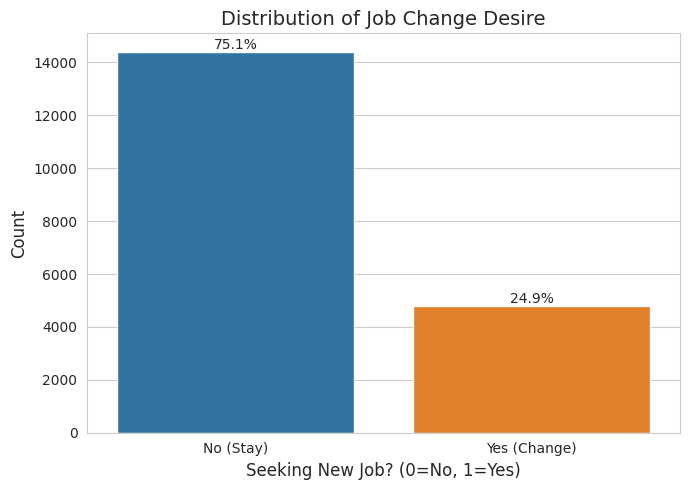

In [77]:
sns.set_style("whitegrid")
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='target', palette='tab10', hue='target', legend=False)
plt.title('Distribution of Job Change Desire', fontsize=14)
plt.xlabel('Seeking New Job? (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['No (Stay)', 'Yes (Change)'], fontsize=10)

# Add percentage annotations
total = len(df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 2. Geographic and Training Motivations (Geography & Training)

**City Development Index (CDI):**

**Observation:** This is the strongest predictive indicator in the data (average 0.82). Candidates from cities with a low development index (less than 0.62) leave and seek new jobs at very high rates. In contrast, residents of developed cities (above 0.65) tend to stay.

**HR Insight:** People in less developed cities use this training as a springboard for economic migration to seek better opportunities. Meanwhile, residents of developed cities already have stability and good jobs that make them uninterested in change.

**Training Hours:**

**Observation:** The distribution is right-skewed (the majority completed less than 100 hours, with an average of 65 hours). Generally, there is no real correlation between the number of hours and company loyalty. Only those who completed less than 150 training hours showed a relatively higher desire to change jobs.

**HR Insight:** The number of training hours does not reflect a candidate's loyalty to the company. HR should not rely on this metric as a primary criterion for predicting who will stay and who will leave.

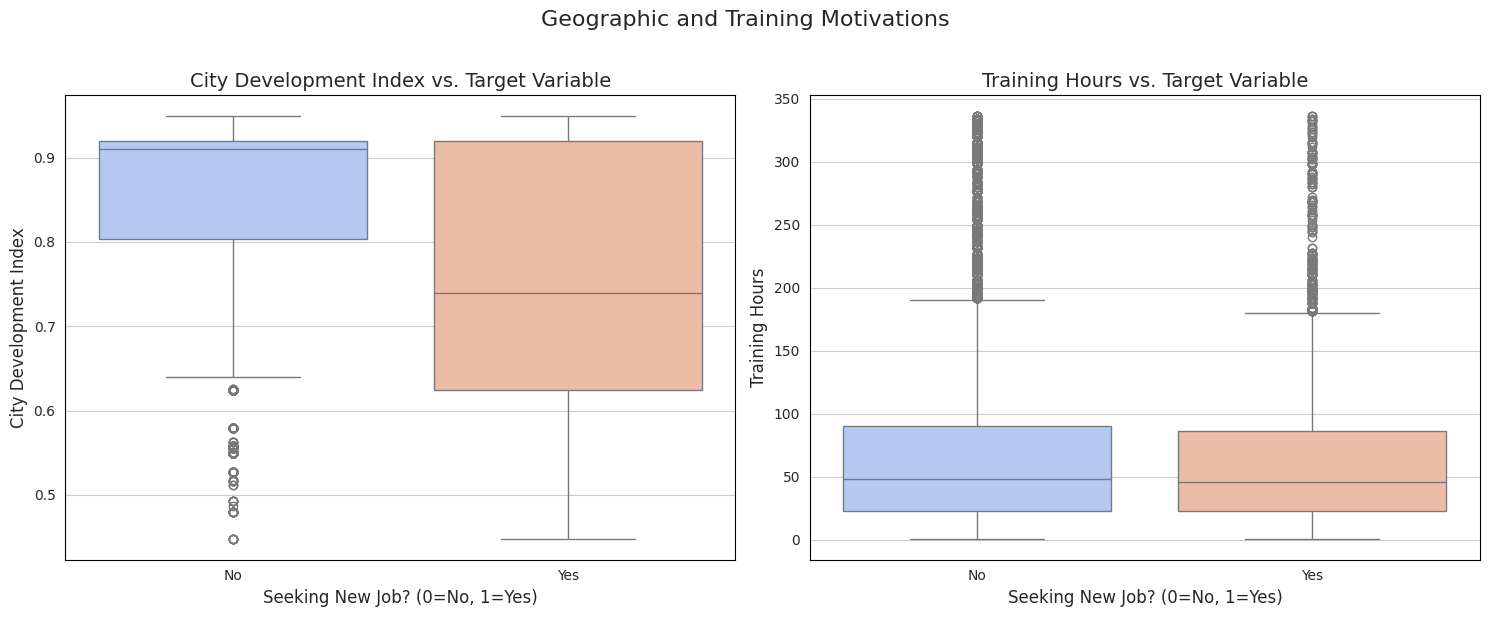

In [78]:
sns.set_style("whitegrid")
plt.figure(figsize=(15, 6))
plt.suptitle('Geographic and Training Motivations', fontsize=16, y=1.02)

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='target', y='city_development_index', palette='coolwarm', hue='target', legend=False)
plt.title('City Development Index vs. Target Variable', fontsize=14)
plt.xlabel('Seeking New Job? (0=No, 1=Yes)', fontsize=12)
plt.ylabel('City Development Index', fontsize=12)
plt.xticks([0, 1], ['No', 'Yes'], fontsize=10)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='target', y='training_hours', palette='coolwarm', hue='target', legend=False)
plt.title('Training Hours vs. Target Variable', fontsize=14)
plt.xlabel('Seeking New Job? (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Training Hours', fontsize=12)
plt.xticks([0, 1], ['No', 'Yes'], fontsize=10)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')

plt.tight_layout()
plt.show()

## 3. Education and Academic Background (Education & Academic Background)

**Enrolled University:**

**Observation:** The majority are not enrolled in a university (no_enrollment). However, current students (whether full-time or part-time) have a higher rate of leaving and seeking employment.

**HR Insight:** Current students use training as a quick entry point into the job market and will seek employment immediately after graduation, making them a high "departure risk."

**Education Level:**

**Observation:** The "Graduate" category is the largest and most willing to change compared to Master's and PhD holders.

**HR Insight:** The analysis suggests that the company should not ignore hiring "High School" graduates, as they can be excellent and loyal candidates if they have prior experience and good training hours.

**Major Discipline:**

**Observation:** STEM disciplines (Science and Technology) are the dominant workforce. As for "Business Administration," those currently studying it (full-time/part-time) are never willing to switch to data science, while those who completed their studies in it show little interest in change.

**HR Insight:** Demand and interest vary significantly by major. Recruitment efforts should focus on STEM disciplines and avoid wasting resources on current Business Administration students.

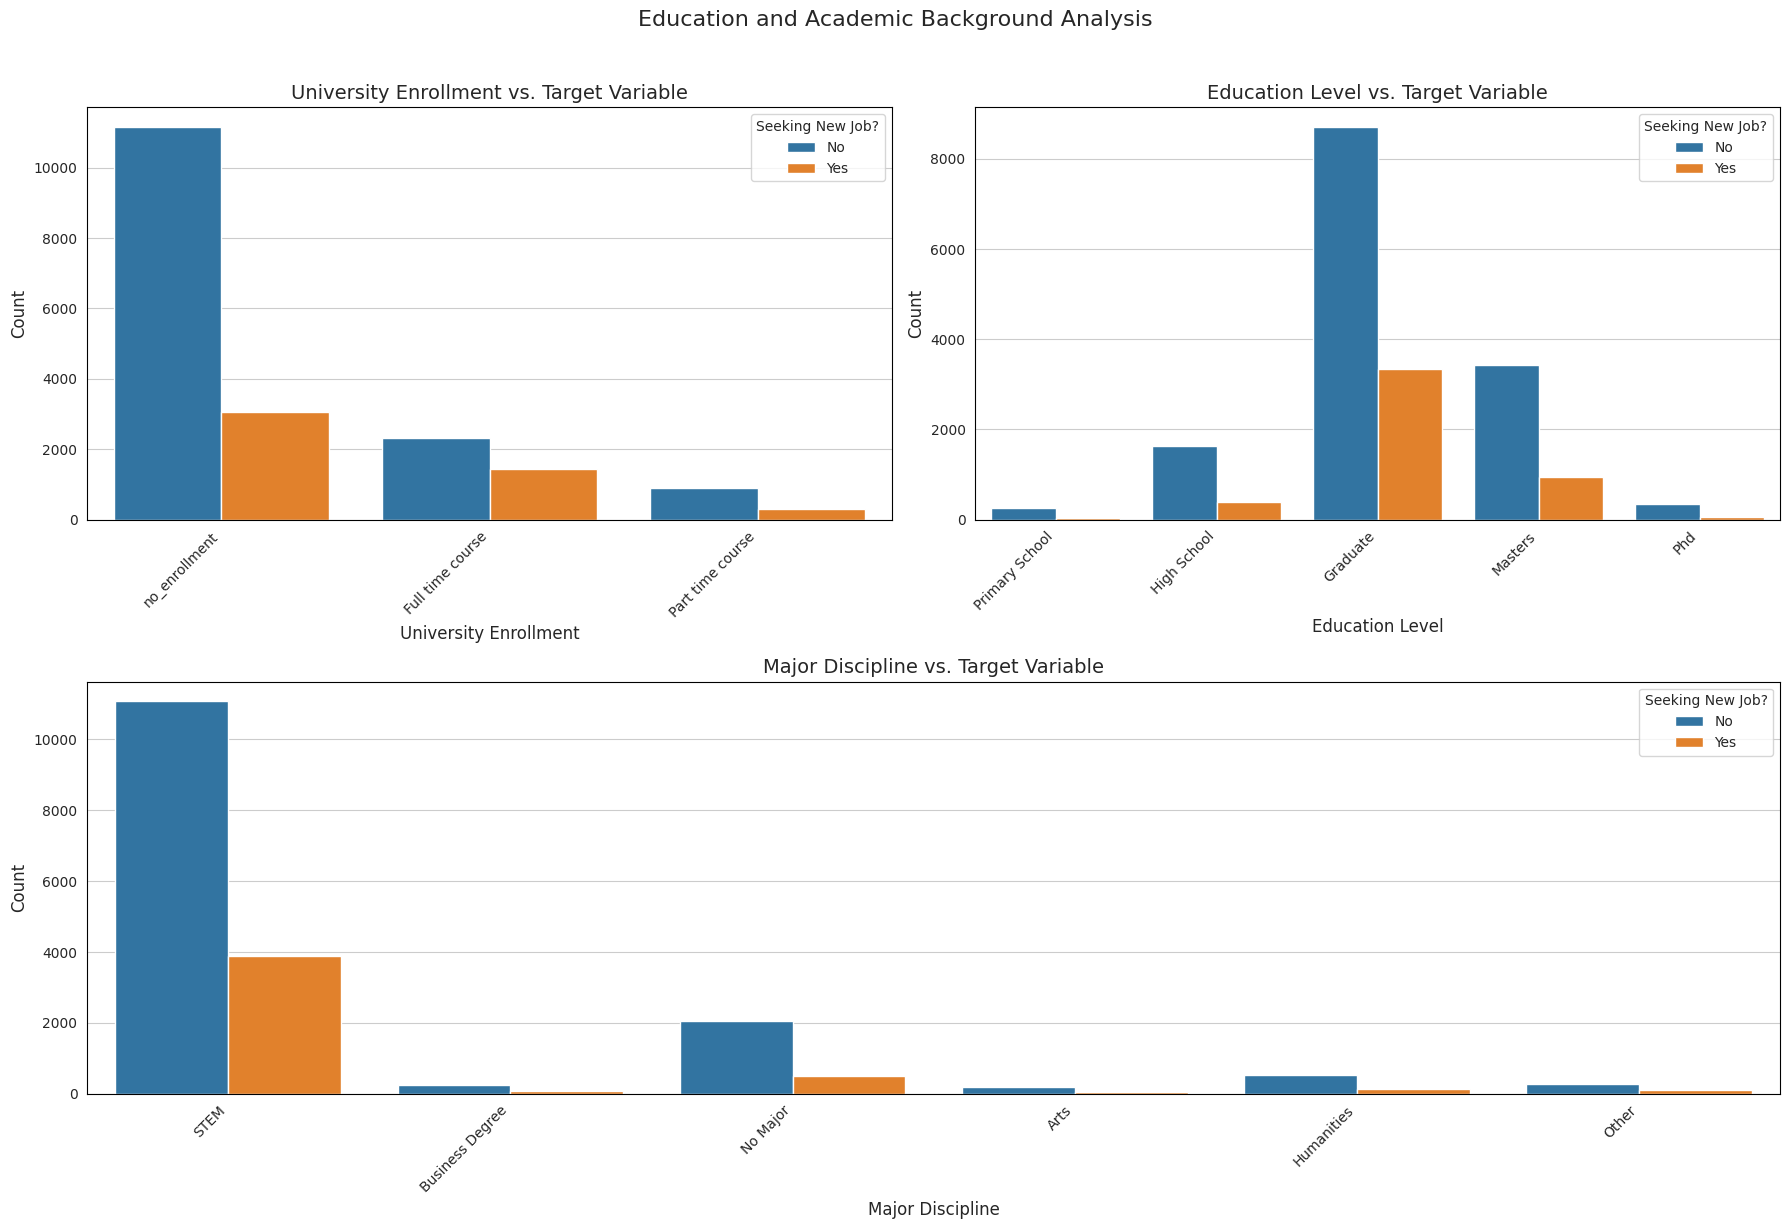

In [79]:
sns.set_style("whitegrid")
plt.figure(figsize=(18, 12))
plt.suptitle('Education and Academic Background Analysis', fontsize=16, y=1.02)

plt.subplot(2, 2, 1)
sns.countplot(data=df, x='enrolled_university', hue='target', palette='tab10')
plt.title('University Enrollment vs. Target Variable', fontsize=14)
plt.xlabel('University Enrollment', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Seeking New Job?', labels=['No', 'Yes'], fontsize=10, title_fontsize=10)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')

plt.subplot(2, 2, 2)
sns.countplot(data=df, x='education_level', hue='target', palette='tab10')
plt.title('Education Level vs. Target Variable', fontsize=14)
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Seeking New Job?', labels=['No', 'Yes'], fontsize=10, title_fontsize=10)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')

plt.subplot(2, 1, 2)
sns.countplot(data=df, x='major_discipline', hue='target', palette='tab10')
plt.title('Major Discipline vs. Target Variable', fontsize=14)
plt.xlabel('Major Discipline', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Seeking New Job?', labels=['No', 'Yes'], fontsize=10, title_fontsize=10)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')

plt.tight_layout()
plt.show()

## 4. Experience and Career History (Experience & Career History)

**Relevant Experience and Total Experience:**

**Observation:** 72% have previous relevant experience in the field. However, individuals who do not have this experience, or entry-level employees, are most actively seeking new jobs. On the other hand, experienced individuals (from 1 to over 20 years), and categories (Mid-Senior, Senior, and Expert) are overwhelmingly inclined not to change.

**HR Insight:** HR should understand the reasons why experienced professionals are reluctant to enter the data science field (often due to their pursuit of stability). Also, providing opportunities to entry-level individuals means accepting a higher turnover rate.

**Time Since Last New Job:**

**Observation:** The majority changed jobs only one year ago. Those who changed jobs recently (one or two years ago) are less likely to seek employment. In contrast, those who have not changed jobs for a long time (more than 4 years or never) are most eager to change.

**HR Insight:** An employee who joined a job recently tends to stay because they have just settled in, while someone who has been in the same job for a long time has a "cumulative desire" to break the routine.

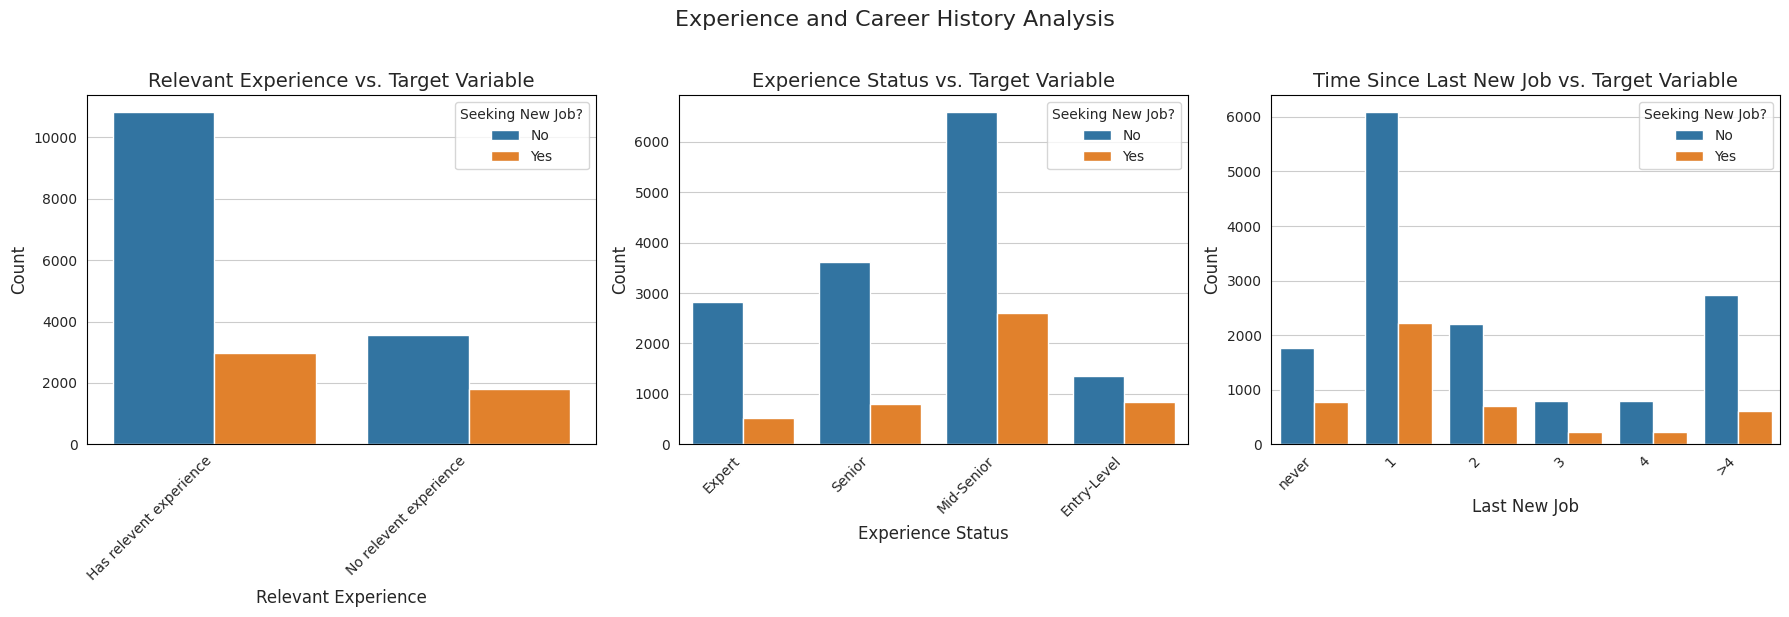

In [80]:
sns.set_style("whitegrid")
plt.figure(figsize=(18, 6))
plt.suptitle('Experience and Career History Analysis', fontsize=16, y=1.02)

plt.subplot(1, 3, 1)
sns.countplot(data=df, x='relevent_experience', hue='target', palette='tab10')
plt.title('Relevant Experience vs. Target Variable', fontsize=14)
plt.xlabel('Relevant Experience', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Seeking New Job?', labels=['No', 'Yes'], fontsize=10, title_fontsize=10)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')

plt.subplot(1, 3, 2)
sns.countplot(data=df, x='experience_status', hue='target', palette='tab10')
plt.title('Experience Status vs. Target Variable', fontsize=14)
plt.xlabel('Experience Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Seeking New Job?', labels=['No', 'Yes'], fontsize=10, title_fontsize=10)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')

plt.subplot(1, 3, 3)
sns.countplot(data=df, x='last_new_job', hue='target', palette='tab10')
plt.title('Time Since Last New Job vs. Target Variable', fontsize=14)
plt.xlabel('Last New Job', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Seeking New Job?', labels=['No', 'Yes'], fontsize=10, title_fontsize=10)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')

plt.tight_layout()
plt.show()

## 5. Work Environment & Demographics

**Company Type & Size:**

**Observation:** The "Medium" size category of companies is the most common. In terms of type, Private Limited (Pvt Ltd) companies of all sizes are the largest "mine" from which individuals willing to transition to data science come (at higher rates than Startups or Public Sector companies).

**HR Insight:** When seeking ready and transferable candidates, HR should primarily target employees from the "Pvt Ltd" sector instead of focusing only on startups.

**Gender:**

**Observation:** 90% of candidates are male. However, when looking at internal percentages, we find that females and the "Other" category have a slightly higher likelihood of seeking a career change compared to males.

**HR Insight:** Despite the male dominance in numbers, there is higher flexibility among other categories in making career change decisions towards data science.

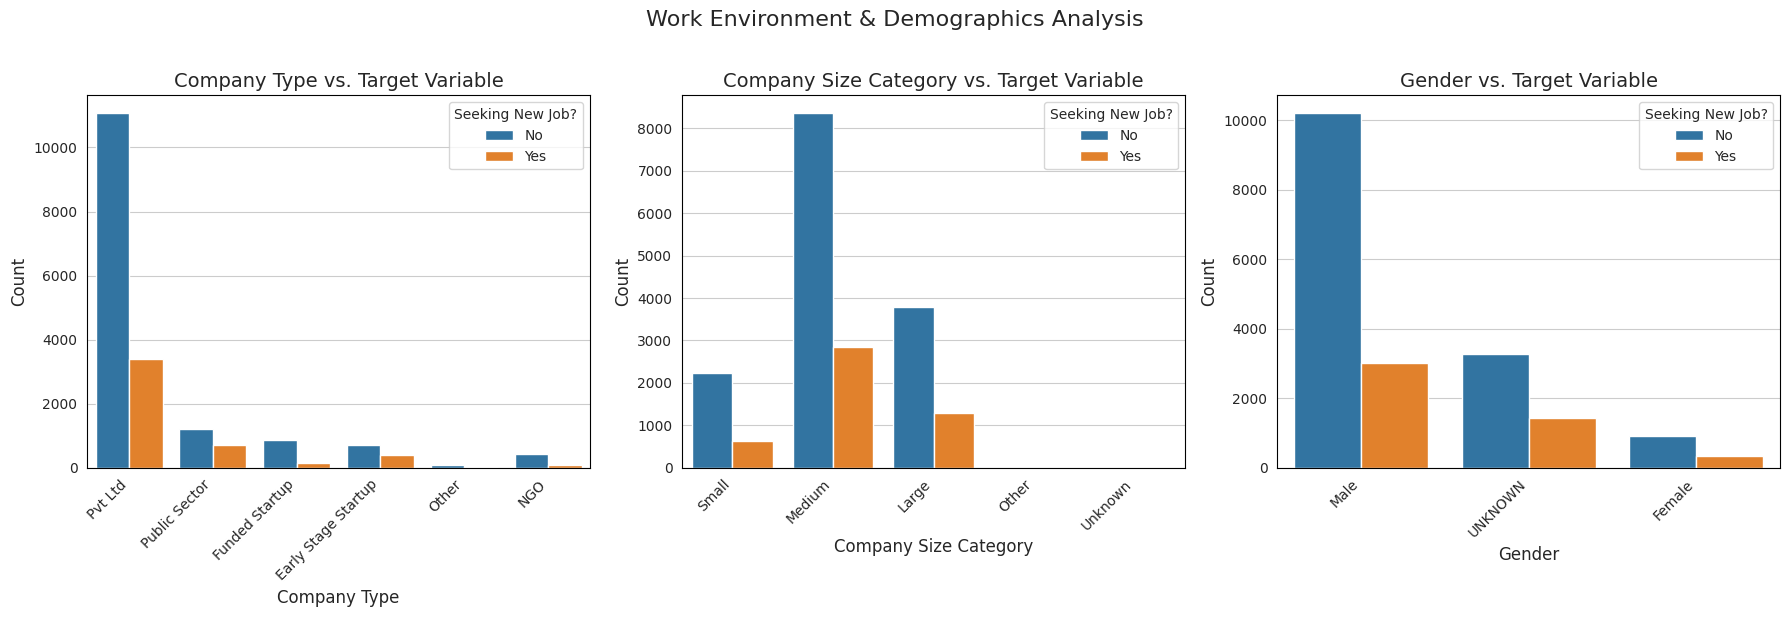

In [81]:
sns.set_style("whitegrid")
plt.figure(figsize=(18, 6))
plt.suptitle('Work Environment & Demographics Analysis', fontsize=16, y=1.02)

plt.subplot(1, 3, 1)
sns.countplot(data=df, x='company_type', hue='target', palette='tab10')
plt.title('Company Type vs. Target Variable', fontsize=14)
plt.xlabel('Company Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Seeking New Job?', labels=['No', 'Yes'], fontsize=10, title_fontsize=10)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')

plt.subplot(1, 3, 2)
sns.countplot(data=df, x='company_size_category', hue='target', palette='tab10')
plt.title('Company Size Category vs. Target Variable', fontsize=14)
plt.xlabel('Company Size Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Seeking New Job?', labels=['No', 'Yes'], fontsize=10, title_fontsize=10)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')

plt.subplot(1, 3, 3)
sns.countplot(data=df, x='gender', hue='target', palette='tab10')
plt.title('Gender vs. Target Variable', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Seeking New Job?', labels=['No', 'Yes'], fontsize=10, title_fontsize=10)
for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')

plt.tight_layout()
plt.show()

In [82]:
# =========================================================# BUSINESS INTELLIGENCE STATS & OPTIONAL BONUS CANDIDATE RANKING# =========================================================print("=== RECRUITMENT STATISTICS (BUSINESS INTELLIGENCE) ===")# 1. Total breakdown of looking vs not lookingtotal_candidates = len(df)looking_for_change = df['target'].sum()percentage_looking = (looking_for_change / total_candidates) * 100print(f"Total Profiles Evaluated: {total_candidates}")print(f"Candidates Seeking a Job Change: {int(looking_for_change)} ({percentage_looking:.1f}%)")# 2. Breakdown by Experience Statusprint("\n=== PROFILE TRENDS BY EXPERIENCE ===")print(df['experience_status'].value_counts(normalize=True) * 100)print("\n=========================================================")print("=== OPTIONAL BONUS: TOP 10 CANDIDATE RECOMMENDATIONS ===")print("=========================================================")# Use your best tuned model to get probabilities of looking for a change# class 1 index is [:, 1]test_probabilities = log_model.predict_proba(X_test_scaled)[:, 1]# Create a ranking DataFrame for the test candidatesranking_df = pd.DataFrame({    'Actual_Status': y_test,    'Probability_Score': test_probabilities})# Sort them from highest probability to lowest and grab the top 10top_10_applicants = ranking_df.sort_values(by='Probability_Score', ascending=False).head(10)print(top_10_applicants)

# ***Logistic Regression***

# ***Encoding***

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
text_columns = df.select_dtypes(include=['object', 'category']).columns

for col in text_columns:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,experience_status,company_size_category
0,8949,5,0.920,1,0,2,0,5,21,0,5,0,36,1.0,1,1
1,29725,77,0.776,1,1,2,0,5,6,3,5,4,47,0.0,3,1
2,11561,64,0.624,2,1,0,0,5,15,2,4,5,83,0.0,2,0
3,33241,14,0.789,2,1,2,0,1,20,3,5,5,52,1.0,0,1
4,666,50,0.767,1,0,2,2,5,21,3,1,3,8,0.0,1,1


# Features & Target Split

In [84]:
X = df.drop(columns=['enrollee_id', 'target'])
y = df['target']

# Train-Test Split

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"training data size: {X_train.shape}")
print(f"testing data size: {X_test.shape}")

training data size: (15326, 14)
testing data size: (3832, 14)


# model training

In [86]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

print("training doneeee")

training doneeee


# evaluation

In [87]:
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
cm_log = confusion_matrix(y_test, y_pred_log)

print("Logistic Regression Results")
print(f"Accuracy ( all): {accuracy_log:.4f}")
print(f"Precision ( specific): {precision_log:.4f}")
print(f"Recall : {recall_log:.4f}")
print(f"F1 Score: {f1_log:.4f}")
print("\nConfusion Matrix:")
print(cm_log)

Logistic Regression Results
Accuracy ( all): 0.7096
Precision ( specific): 0.4416
Recall : 0.6397
F1 Score: 0.5225

Confusion Matrix:
[[2110  770]
 [ 343  609]]


In [88]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Define the parameters we want to tweak
param_distributions = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced'] # Direct fix for the imbalanced data!
}

# 2. Initialize the search (cv=3 means it tests combinations using 3-fold cross-validation)
rf_tune = RandomForestClassifier(random_state=42)
search = RandomizedSearchCV(estimator=rf_tune, param_distributions=param_distributions,
                            n_iter=5, cv=3, random_state=42, n_jobs=-1)

print("Tuning the model... Please wait a moment...")
search.fit(X_train, y_train)

# 3. Get the best model settings found
best_rf_model = search.best_estimator_
print(f"Best settings found: {search.best_params_}\n")

# 4. Predict and evaluate the tuned model
y_pred_tuned = best_rf_model.predict(X_test)

print("--- TUNED MODEL EVALUATION SCORES ---")
print(classification_report(y_test, y_pred_tuned))

print("--- TUNED CONFUSION MATRIX ---")
print(confusion_matrix(y_test, y_pred_tuned))

Tuning the model... Please wait a moment...
Best settings found: {'n_estimators': 150, 'min_samples_split': 10, 'max_depth': 10, 'class_weight': 'balanced'}

--- TUNED MODEL EVALUATION SCORES ---
              precision    recall  f1-score   support

         0.0       0.87      0.82      0.84      2880
         1.0       0.53      0.62      0.57       952

    accuracy                           0.77      3832
   macro avg       0.70      0.72      0.71      3832
weighted avg       0.78      0.77      0.77      3832

--- TUNED CONFUSION MATRIX ---
[[2352  528]
 [ 358  594]]


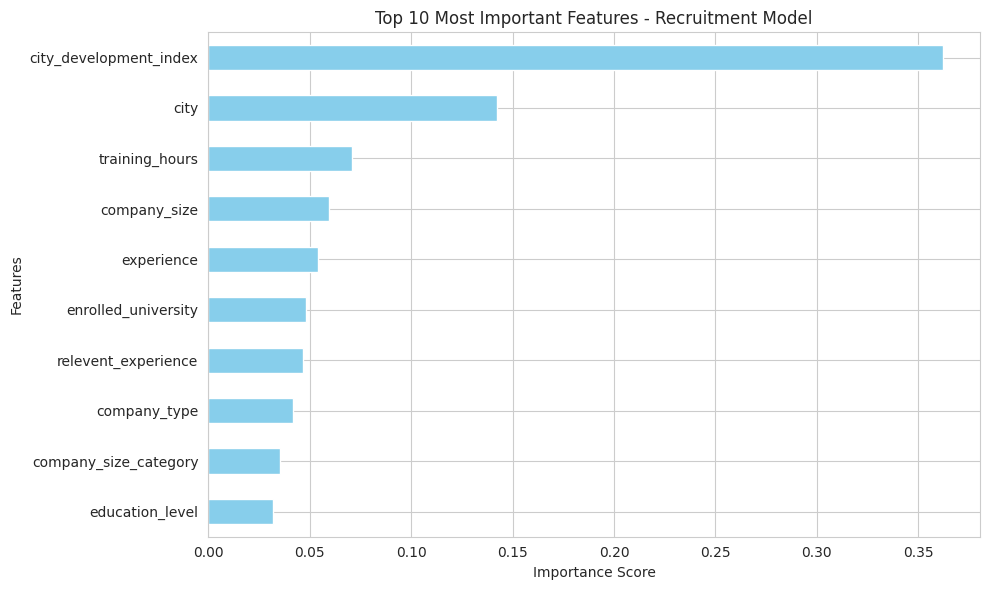

In [90]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract feature importances from your trained Random Forest model
importances = best_rf_model.feature_importances_
feature_names = X.columns

# 2. Put them into a series and sort them from highest to lowest
feature_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 3. Take the top 10 most influential features
top_10_features = feature_imp.head(10)

# 4. Plot a simple horizontal bar chart
plt.figure(figsize=(10, 6))
top_10_features.sort_values().plot(kind='barh', color='skyblue')
plt.title('Top 10 Most Important Features - Recruitment Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

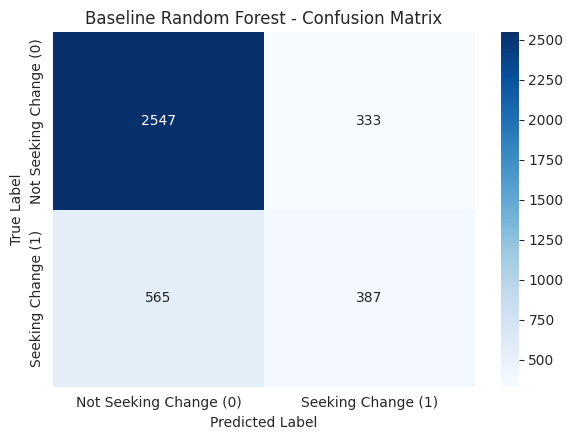

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Grab the raw matrix numbers from your previous run output
cm = [[2547, 333],
      [565, 387]]

# 2. Draw the heatmap visualization
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Seeking Change (0)', 'Seeking Change (1)'],
            yticklabels=['Not Seeking Change (0)', 'Seeking Change (1)'])

# 3. Add clean report formatting labels
plt.title('Baseline Random Forest - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [92]:
# =========================================================
# BUSINESS INTELLIGENCE STATS & OPTIONAL BONUS CANDIDATE RANKING
# =========================================================

print("=== RECRUITMENT STATISTICS (BUSINESS INTELLIGENCE) ===")
# 1. Total breakdown of looking vs not looking
total_candidates = len(df)
looking_for_change = df['target'].sum()
percentage_looking = (looking_for_change / total_candidates) * 100
print(f"Total Profiles Evaluated: {total_candidates}")
print(f"Candidates Seeking a Job Change: {int(looking_for_change)} ({percentage_looking:.1f}%)")

# 2. Breakdown by Experience Status
print("\n=== PROFILE TRENDS BY EXPERIENCE ===")
print(df['experience_status'].value_counts(normalize=True) * 100)


print("\n=========================================================")
print("=== OPTIONAL BONUS: TOP 10 CANDIDATE RECOMMENDATIONS ===")
print("=========================================================")
# Use your best tuned model to get probabilities of looking for a change
# class 1 index is [:, 1]
test_probabilities = best_rf_model.predict_proba(X_test)[:, 1]

# Create a ranking DataFrame for the test candidates
ranking_df = pd.DataFrame({
    'Actual_Status': y_test,
    'Probability_Score': test_probabilities
})

# Sort them from highest probability to lowest and grab the top 10
top_10_applicants = ranking_df.sort_values(by='Probability_Score', ascending=False).head(10)
print(top_10_applicants)

=== RECRUITMENT STATISTICS (BUSINESS INTELLIGENCE) ===
Total Profiles Evaluated: 19158
Candidates Seeking a Job Change: 4777 (24.9%)

=== PROFILE TRENDS BY EXPERIENCE ===
experience_status
2    48.032154
3    23.024324
1    17.465289
0    11.478234
Name: proportion, dtype: float64

=== OPTIONAL BONUS: TOP 10 CANDIDATE RECOMMENDATIONS ===
       Actual_Status  Probability_Score
11642            1.0           0.882204
99               1.0           0.870488
2701             0.0           0.870089
12138            1.0           0.869605
1087             1.0           0.867147
18100            1.0           0.865680
14584            0.0           0.865458
1063             0.0           0.861800
14121            1.0           0.860113
8072             1.0           0.858569
